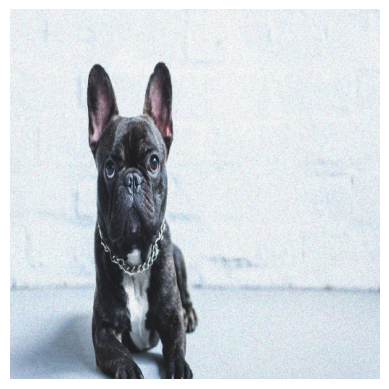

In [138]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('input.jpeg')
img = cv2.resize(img, (512, 512))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

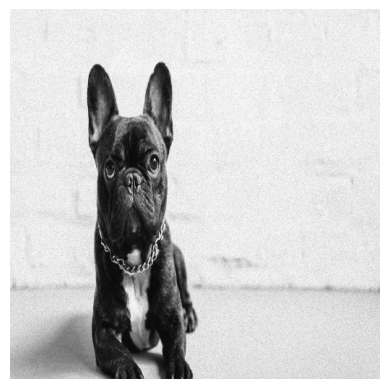

array([[230.33333333, 241.33333333, 234.66666667, ..., 233.33333333,
        241.66666667, 235.33333333],
       [242.33333333, 234.66666667, 244.        , ..., 227.        ,
        244.33333333, 235.33333333],
       [249.33333333, 248.66666667, 233.        , ..., 240.        ,
        221.33333333, 241.33333333],
       ...,
       [196.66666667, 176.33333333, 196.33333333, ..., 215.66666667,
        227.66666667, 221.33333333],
       [205.33333333, 194.66666667, 189.        , ..., 215.33333333,
        222.        , 226.33333333],
       [194.        , 212.66666667, 212.66666667, ..., 223.33333333,
        223.33333333, 219.        ]], shape=(512, 512))

In [139]:
img_gray = np.mean(img, axis=2)
plt.imshow(img_gray, cmap="gray")
plt.axis("off")
plt.show()
img_gray

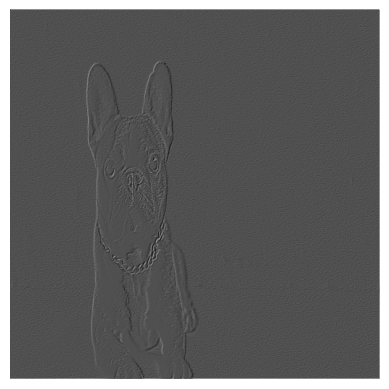

In [140]:
def convolve(img, kernel):
    img_h, img_w = img.shape
    ker_h, ker_w = kernel.shape

    pad_h = ker_h // 2
    pad_w = ker_w // 2

    padded = np.pad(
        img,
        ((pad_h, pad_h), (pad_w, pad_w)),
        mode='constant'
    )
    
    kernel = np.flipud(np.fliplr(kernel))
    
    output = np.zeros((img_h, img_w))

    for i in range(img_h):
        for j in range(img_w):
            region = padded[i:i+ker_h, j:j+ker_w]
            output[i, j] = np.sum(region * kernel)
            
    return output

dummy_kernel = np.array([
    [-1, 0, 0],
    [0, 1, 1],
    [0, 0, -1]])

plt.imshow(convolve(img_gray, dummy_kernel), cmap="gray")
plt.axis("off")
plt.show()

In [141]:
def gaussian_kernel(size=5, sigma=1.0):
    ax = np.arange(-size // 2 + 1, size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)

    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / np.sum(kernel)
    
    return kernel

gaussian_kernel(5, 1) * 256

array([[ 0.76006829,  3.40638973,  5.61618721,  3.40638973,  0.76006829],
       [ 3.40638973, 15.26637963, 25.17000483, 15.26637963,  3.40638973],
       [ 5.61618721, 25.17000483, 41.49832234, 25.17000483,  5.61618721],
       [ 3.40638973, 15.26637963, 25.17000483, 15.26637963,  3.40638973],
       [ 0.76006829,  3.40638973,  5.61618721,  3.40638973,  0.76006829]])

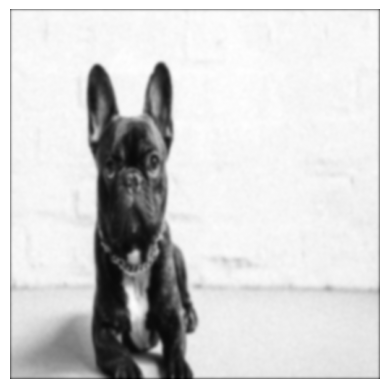

In [142]:
def gaussian_blur(img, sigma=1.0):
    size = 6 * sigma + 1
    if size % 2 == 0:
        size += 1

    kernel = gaussian_kernel(size, sigma)
    return convolve(img, kernel)

blurred = gaussian_blur(img_gray, 2)
plt.imshow(blurred, cmap="gray")
plt.axis("off")
plt.show()

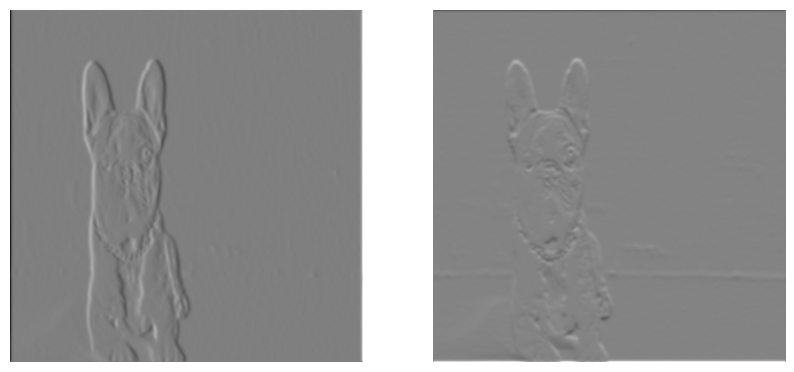

In [143]:
kernel_sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

kernel_sobel_y = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
])

gx = convolve(blurred, kernel_sobel_x)
gy = convolve(blurred, kernel_sobel_y)

fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(gx, cmap="gray")
axes[0].axis("off")

axes[1].imshow(gy, cmap="gray")
axes[1].axis("off")

plt.show()

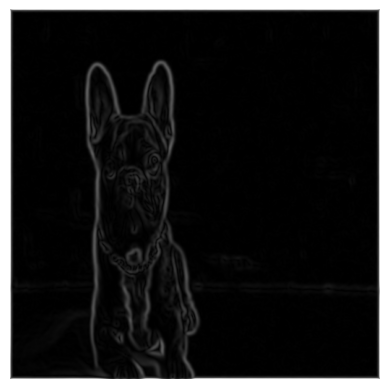

In [144]:
def sobel(img):
    kernel_sobel_x = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ])

    kernel_sobel_y = np.array([
        [-1, -2, -1],
        [0, 0, 0],
        [1, 2, 1]
    ])

    gx = convolve(img, kernel_sobel_x)
    gy = convolve(img, kernel_sobel_y)

    magnitude = np.hypot(gx, gy)
    magnitude = magnitude / magnitude.max() * 255
    theta = np.arctan2(gy, gx)

    return magnitude, theta

magnitude, theta = sobel(blurred)
plt.imshow(magnitude, cmap="gray")
plt.axis("off")
plt.show()


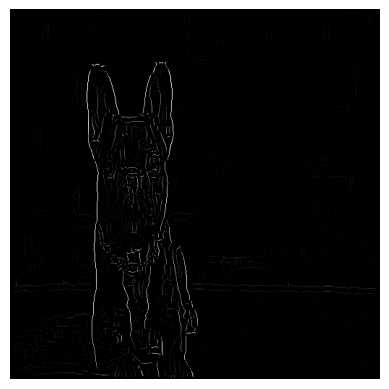

In [145]:
def non_max_suppression(img, theta):
    img_w, img_h = img.shape
    output = np.zeros((img_w,img_h))
    angle = theta * 180. / np.pi
    angle[angle < 0] += 180
    
    for i in range(1,img_w-1):
        for j in range(1,img_h-1):
            try:
                q = 255
                r = 255
                
               # 0*
                if (0 <= angle[i,j] < 22.5) or (157.5 <= angle[i,j] <= 180):
                    q = img[i, j+1]
                    r = img[i, j-1]
                # 45*
                elif (22.5 <= angle[i,j] < 67.5):
                    q = img[i+1, j-1]
                    r = img[i-1, j+1]
                # 90*
                elif (67.5 <= angle[i,j] < 112.5):
                    q = img[i+1, j]
                    r = img[i-1, j]
                # 135*
                elif (112.5 <= angle[i,j] < 157.5):
                    q = img[i-1, j-1]
                    r = img[i+1, j+1]

                if (img[i,j] >= q) and (img[i,j] >= r):
                    output[i,j] = img[i,j]
                else:
                    output[i,j] = 0

            except IndexError as e:
                pass
    
    return output

supressed = non_max_suppression(magnitude, theta)
plt.imshow(supressed, cmap="gray")
plt.axis("off")
plt.show()

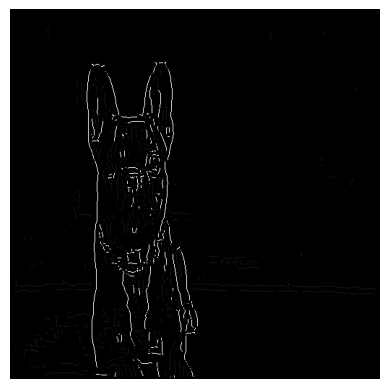

In [146]:
def threshold(img, lowThresholdRatio=0.2, highThresholdRatio=0.3):
    
    highThreshold = img.max() * highThresholdRatio
    lowThreshold = highThreshold * lowThresholdRatio
    
    img_w, img_h = img.shape
    res = np.zeros((img_w, img_h))
    
    weak = np.int32(25)
    strong = np.int32(255)
    
    strong_i, strong_j = np.where(img >= highThreshold)
    weak_i, weak_j = np.where((img <= highThreshold) & (img >= lowThreshold))
    
    res[strong_i, strong_j] = strong
    res[weak_i, weak_j] = weak
    
    return (res, weak, strong)

thresholded, weak, strong = threshold(supressed)
plt.imshow(thresholded, cmap="gray")
plt.axis("off")
plt.show()


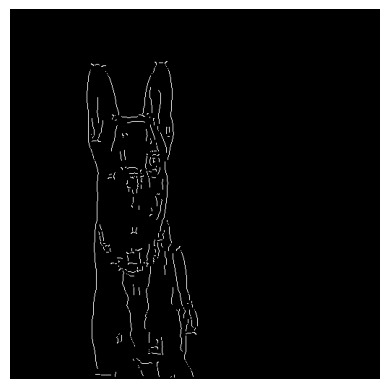

In [147]:
def hysteresis(img, weak, strong=255):
    M, N = img.shape  
    for i in range(1, M-1):
        for j in range(1, N-1):
            if (img[i,j] == weak):
                try:
                    if ((img[i+1, j-1] == strong) or (img[i+1, j] == strong) or (img[i+1, j+1] == strong)
                        or (img[i, j-1] == strong) or (img[i, j+1] == strong)
                        or (img[i-1, j-1] == strong) or (img[i-1, j] == strong) or (img[i-1, j+1] == strong)):
                        img[i, j] = strong
                    else:
                        img[i, j] = 0
                except IndexError as e:
                    pass
    return img

hysteresized = hysteresis(thresholded, weak, strong)
plt.imshow(hysteresized, cmap="gray")
plt.axis("off")
plt.show()

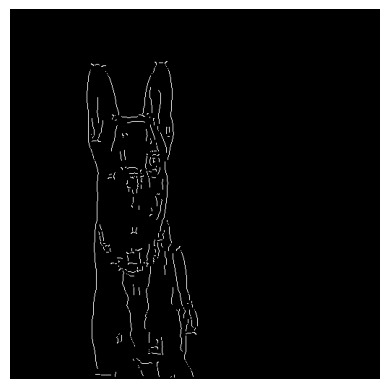

In [152]:
def edge_detector(img, sigma):
    img = np.mean(img, axis=2)
    img = gaussian_blur(img, sigma)
    img, theta = sobel(img)
    img = non_max_suppression(img, theta)
    img, weak, strong = threshold(img)
    img = hysteresis(img, weak, strong)
    return img

img_edges = edge_detector(img, 2)
plt.imshow(img_edges, cmap="gray")
plt.axis("off")
plt.show()